#### 목차  
- [회귀 모델](#회귀-모델)
    * [선형 회귀](#선형-회귀)
    * [다항 회귀](#다항-회귀)
    * [규제가 있는 선형 모델](#규제가-있는-선형-모델)
        * [릿지 회귀](#릿지-회귀)
        * [라쏘 회귀](#라쏘-회귀)
        * [엘라스틱넷](#엘라스틱넷)
    * [로지스틱 회귀](#로지스틱-회귀)
    * [회귀모델 실제 데이터셋에 적용시켜보기](#회귀모델-실제-데이터셋에-적용시켜보기)
        * [Preprocessing](#Preprocessing)
        * [Modeling](#Modeling)

- [분류 모델](#분류-모델)
    * [SVM](#SVM)  
        * [하이퍼파라미터](#SVC-하이퍼파라미터)  
        * [선형 SVM](#선형-SVM)  
        * [hard margin vs soft margin](#hard-margin-vs-soft-margin)
        * [비선형 SVM](#비선형-SVM)  
    * [KNN](#KNN)
        * [하이퍼파라미터](#KNN-하이퍼파라미터) 
        * [비교해보기](#비교해보기)
    * [Decision Tree](#Decision-Tree)
        * [DT 하이퍼파라미터](#DT-하이퍼파라미터)
        * [결정 트리 학습&시각화](#결정-트리-학습&시각화)
        * [클래스 확률 추정](#클래스-확률-추정)
        * [파라미터 변경](#파라미터-변경)
        * [데이터셋 회전](#데이터셋을-회전할-경우)

# ML Session 3주차 회귀 & 분류모델

# 회귀 모델  
회귀분석: 독립 변수 x에 대응하는 종속 변수 y와 가장 비슷한 값 y-hat을 출력하는 함수 f(x)를 찾는 과정

## 선형 회귀
f(x)가 선형 함수인 회귀모형이면 선형 회귀분석  

Loss function(손실함수)?  
실제값과 예측값의 차이를 나타낸 특정 함수/ 회귀에서는 MSE,MAE가 손실함수

손실함수 = 개별 값들에 대한 오차  
비용함수 = 모든 값들에 대한 평균손실

* 랜덤하게 선형적인 데이터셋 생성

In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = 2 * np.random.rand(100, 1) #균일분포에서 난수 생성 (0,1 사이 값)
y = 4 + 3 * X + np.random.randn(100, 1) #정규분포에서 난수 생성 (평균 0이고 표준편차 1을 따르는 값)

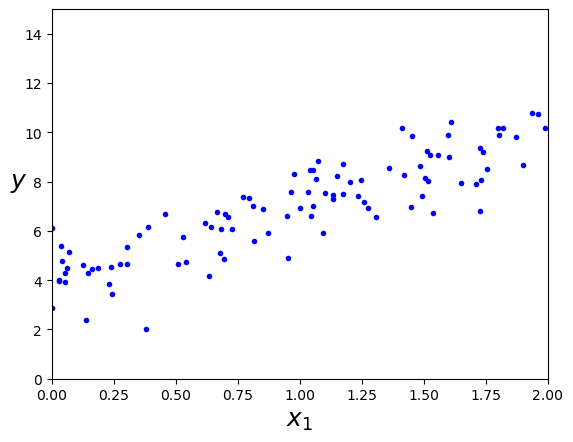

In [2]:
plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.show()

* 만약 위와 같은 input(독립변수 x)와 output(종속변수 y)를 갖는 자연현상이나 과학실험이 있다면?
* 인간의 경우 몇 백년에 걸쳐 수학자와 과학자들이 연구를 하다가 천재가 태어나 데이터를 설명할 수 있는 공식을 발견
* 인공지능의 경우는? -> 주어진 데이터를 학습해 빠르게 결과를 도출

In [3]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_      # 편향, 회귀계수
##      y절편       편향

(array([3.98832908]), array([[3.02245431]]))

* 실제값과의 오차가 있지만, 이는 허용 가능한 오차 수준 (이 예제에서는 아니지만, 데이터가 많고 학습이 잘 된 경우)
* 인간과 다르게 빠르게 결과를 낼 수 있음

## 다항 회귀

* 비선형적인 곡선을 그리는 데이터셋 생성

In [4]:
import numpy as np
import numpy.random as rnd

np.random.seed(42)

In [5]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

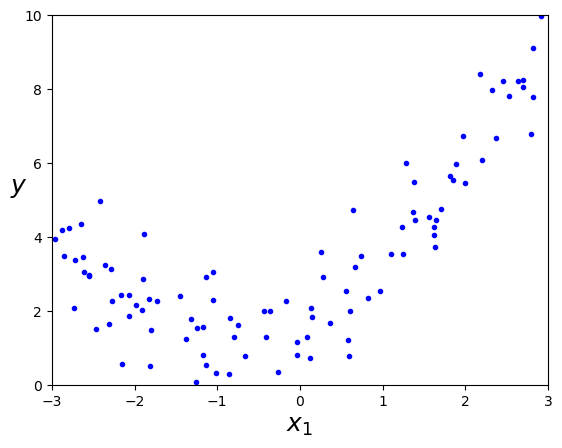

In [6]:
plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
plt.show()

In [7]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

* PolynomialFeatures 모듈을 사용해 degree = 2, 2차 다항식으로 생성  
입력 데이터의 피처(특징)를 다항식(polynomial) 피처로 확장해주는 기능  
이를 통해 선형 모델에도 비선형 관계를 학습할 수 있게 만듦

In [8]:
X_poly[:5] # 1열 = 원본 피처값(1차항), 2열 = 원본 피처의 제곱값(2차항)

array([[-0.75275929,  0.56664654],
       [ 2.70428584,  7.3131619 ],
       [ 1.39196365,  1.93756281],
       [ 0.59195091,  0.35040587],
       [-2.06388816,  4.25963433]])

* 주어진 독립변수의 제곱된(2차항)의 독립변수 생성

In [9]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

* 임의로 정한 편향, 독립변수들의 가중치(회귀계수)를 잘 학습함

## 규제가 있는 선형 모델

* 랜덤한 데이터셋 생성

In [10]:
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

### 릿지 회귀
기존 손실함수 + 세타에 대한 L2규제 추가  
a: 규제 정도를 조절하는 하이퍼 파라미터  
세타의 전체적인 크기에 제약을 줘서 기울기 값을 작게해 급격한 변화를 줄임(0이 되지않음)

==> 모든 특성이 모델에 기여하도록 하여, 과적합을 방지

**릿지 회귀의 비용 함수**

$
J(\boldsymbol{\theta}) = \text{MSE}(\boldsymbol{\theta}) + \alpha \dfrac{1}{2}\sum\limits_{i=1}^{n}{\theta_i}^2
$

In [11]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1, random_state=42)
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([[1.55071465]])

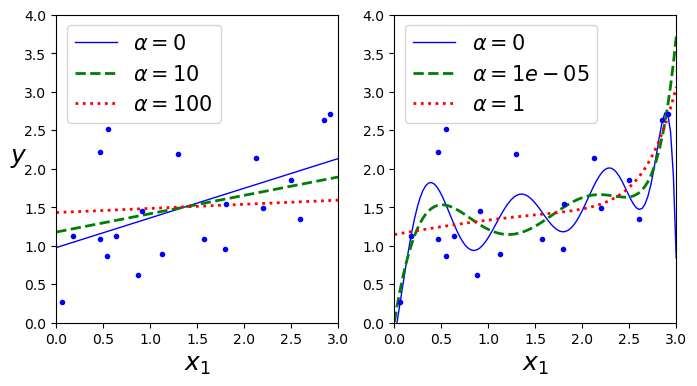

In [12]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def plot_model(model_class, polynomial, alphas, **model_kargs):
    for alpha, style in zip(alphas, ("b-", "g--", "r:")):
        ## 만약 alpha가 0보다 크면 Ridge, 그렇지 않으면 LinearRegression
        model = model_class(alpha, **model_kargs) if alpha > 0 else LinearRegression()
        if polynomial:
            model = Pipeline([
                    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
                    ("std_scaler", StandardScaler()),
                    ("regul_reg", model),
                ])
        model.fit(X, y)
        y_new_regul = model.predict(X_new)
        lw = 2 if alpha > 0 else 1
        plt.plot(X_new, y_new_regul, style, linewidth=lw, label=r"$\alpha = {}$".format(alpha))
    plt.plot(X, y, "b.", linewidth=3)
    plt.legend(loc="upper left", fontsize=15)
    plt.xlabel("$x_1$", fontsize=18)
    plt.axis([0, 3, 0, 4])

    
plt.figure(figsize=(8,4))
plt.subplot(121)
plot_model(Ridge, polynomial=False, alphas=(0, 10, 100), random_state=42)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.subplot(122)
plot_model(Ridge, polynomial=True, alphas=(0, 10**-5, 1), random_state=42)

plt.show()

* alpha값의 변화에 따라 모델의 복잡도가 변화
* alpha가 커지면? -> 규제항에 대한 손실함수에서의 비율이 증가해 규제가 증가 -> 모델이 단순해짐

### 라쏘 회귀
기존 손실함수 + 세타에 대한 L1규제 추가  
a: 규제 정도를 조절하는 하이퍼 파라미터  
세타의 전체적인 크기에 제약을 줘서 기울기 값을 작게해 급격한 변화를 줄임(0도 가능)

==> 가중치(기울기)를 0으로 만들어서 중요하지 않은 feature를 제거할 수 있음

**라쏘 회귀의 비용 함수**

$
J(\boldsymbol{\theta}) = \text{MSE}(\boldsymbol{\theta}) + \alpha \sum\limits_{i=1}^{n}\left| \theta_i \right|
$

C:\Users\touch\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.803e+00, tolerance: 9.295e-04
  model = cd_fast.enet_coordinate_descent(


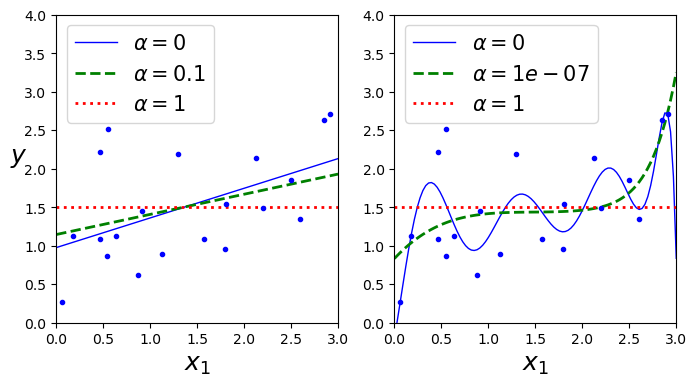

In [13]:
from sklearn.linear_model import Lasso

plt.figure(figsize=(8,4))
plt.subplot(121)
plot_model(Lasso, polynomial=False, alphas=(0, 0.1, 1), random_state=42)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.subplot(122)
plot_model(Lasso, polynomial=True, alphas=(0, 10**-7, 1), random_state=42)

plt.show()

* alpha가 증가함에 따른 모델 복잡도의 변화는 Ridge회귀와 동일
* Ridge회귀와 비교해 규제항에 따른 규제가 더 크게 작용해 alpha를 조금만 증가시켜도 모델의 변화가 큼
* 특성을 빠르게 0에 수렴하는 성질을 갖고있음 
*     -> 데이터셋에서 alpha를 조금만 증가시켰는데 회귀선이 수평에 가까워짐 -> 가중치가 0에 가까워짐

## 로지스틱 회귀
회귀를 사용해 데이터가 어떤 범주에 속할 확률을 0에서 1 사이의 값으로 예측,  
그 확률에 따라 가능성이 더 높은 범주에 속하는 것으로 분류

In [14]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# StandardScaler( )로 평균이 0, 분산 1로 데이터 분포도 변환
scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

X_train , X_test, y_train , y_test = train_test_split(data_scaled, cancer.target, test_size=0.3, random_state=0)

In [16]:
from sklearn.metrics import accuracy_score, roc_auc_score

# 로지스틱 회귀를 이용하여 학습 및 예측 수행. 
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_preds = lr_clf.predict(X_test)

# accuracy와 roc_auc 측정
print('accuracy: {:0.3f}'.format(accuracy_score(y_test, lr_preds)))
print('roc_auc: {:0.3f}'.format(roc_auc_score(y_test , lr_preds)))

accuracy: 0.977
roc_auc: 0.972


## 회귀모델 실제 데이터셋에 적용시켜보기

In [17]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

house_df = pd.read_csv('./data/train.csv')

In [18]:
house_df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [19]:
house_df.shape

(1460, 81)

### Preprocessing

In [20]:
# target 로그 변환
house_df['SalePrice'] = np.log1p(house_df['SalePrice'])

* log변환은 왜곡도가 높은 데이터를 정규분포에 가깝게 변환시켜주는 훌륭한 feature Engineering 방식입니다.
* 기본적으로 선형 회귀는 여러가지 가정을 기반으로 적용됩니다.
* 이 중 대표적인게 예측 오류값이 정규분포 형태를 가진다는 것인데, target값이 왜곡되어 있으면 이러한 가정에서 동떨어지게 됩니다.
* 따라서 이러한 경우 target값을 log 변환한 후 학습과 평가에 사용하고, 도출된 예측값을 활용하는 경우에는 역으로 변환해 사용합니다.

In [21]:
# 불필요한 columns 삭제
house_df = house_df.drop(['Id','PoolQC' , 'MiscFeature', 'Alley', 'Fence','FireplaceQu'], axis=1)

# 숫자형 columns 결측값 평균으로 치환 
house_df = house_df.fillna(house_df.mean(numeric_only=True))
# 범주형 columns One-hot-Encoding
house_df = pd.get_dummies(house_df)

### Modeling

In [22]:
def get_rmse(model):
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test , pred)
    rmse = np.sqrt(mse)
    print('{0} 로그 변환된 RMSE: {1}'.format(model.__class__.__name__,np.round(rmse, 3)))
    return rmse

def get_rmses(models):
    rmses = [ ]
    for model in models:
        rmse = get_rmse(model)
        rmses.append(rmse)
    return rmses

In [23]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

y_target = house_df['SalePrice']
X_features = house_df.drop('SalePrice',axis=1, inplace=False)

X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.2, random_state=156)

# LinearRegression, Ridge, Lasso 학습, 예측, 평가
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)

ridge_reg = Ridge()
ridge_reg.fit(X_train, y_train)

lasso_reg = Lasso()
lasso_reg.fit(X_train, y_train)

ElasticNet = ElasticNet()
ElasticNet.fit(X_train, y_train)

models = [lr_reg, ridge_reg, lasso_reg, ElasticNet]
get_rmses(models)

LinearRegression 로그 변환된 RMSE: 0.132
Ridge 로그 변환된 RMSE: 0.127
Lasso 로그 변환된 RMSE: 0.176
ElasticNet 로그 변환된 RMSE: 0.171


[0.13183184688250207,
 0.12740582836266193,
 0.17628250556471395,
 0.17111817461562784]

In [24]:
def get_top_bottom_coef(model):
    # coef_(가중치 나타냄) 속성을 기반으로 Series 객체를 생성. index는 컬럼명. 
    coef = pd.Series(model.coef_, index=X_features.columns)
    
    # + 상위 10개 , - 하위 10개 coefficient 추출하여 반환.
    coef_high = coef.sort_values(ascending=False).head(10)
    coef_low = coef.sort_values(ascending=False).tail(10)
    return coef_high, coef_low

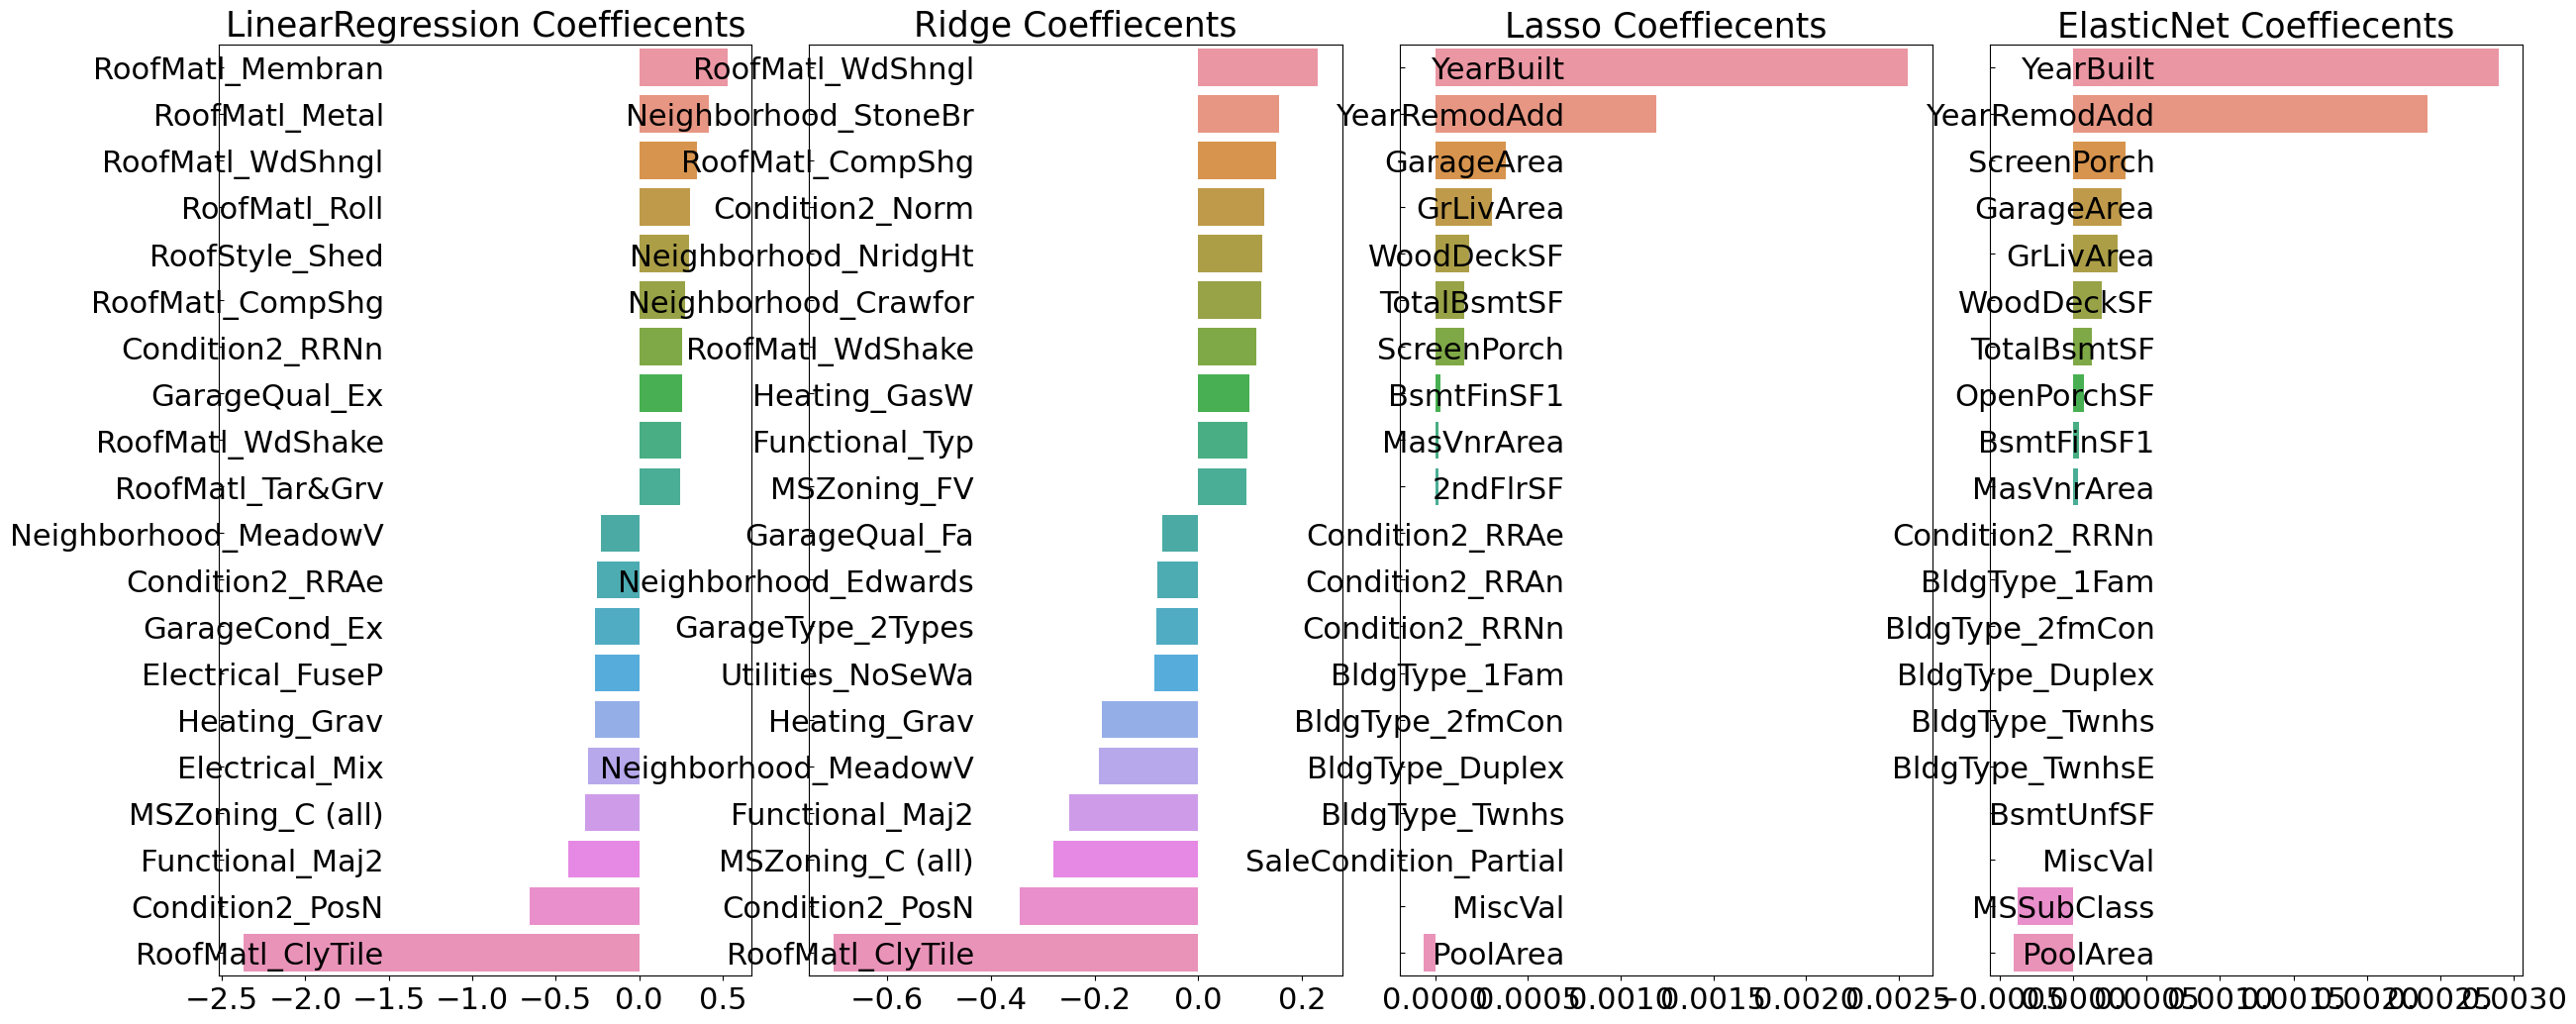

In [25]:
def visualize_coefficient(models):
    # 3개 회귀 모델의 시각화를 위해 3개의 컬럼을 가지는 subplot 생성
    fig, axs = plt.subplots(figsize=(24,10),nrows=1, ncols=4)
    fig.tight_layout() 
    # 입력인자로 받은 list객체인 models에서 차례로 model을 추출하여 회귀 계수 시각화. 
    for i_num, model in enumerate(models):
        # 상위 10개, 하위 10개 회귀 계수를 구하고, 이를 판다스 concat으로 결합. 
        coef_high, coef_low = get_top_bottom_coef(model)
        coef_concat = pd.concat( [coef_high , coef_low] )
        # 순차적으로 ax subplot에 barchar로 표현. 한 화면에 표현하기 위해 tick label 위치와 font 크기 조정. 
        axs[i_num].set_title(model.__class__.__name__+' Coeffiecents', size=25)
        axs[i_num].tick_params(axis="y",direction="in", pad=-120)
        for label in (axs[i_num].get_xticklabels() + axs[i_num].get_yticklabels()):
            label.set_fontsize(22)
        sns.barplot(x=coef_concat.values, y=coef_concat.index , ax=axs[i_num])

# 앞 예제에서 학습한 lr_reg, ridge_reg, lasso_reg 모델의 회귀 계수 시각화.    
models = [lr_reg, ridge_reg, lasso_reg, ElasticNet]
visualize_coefficient(models)

# 분류 모델

In [26]:
import pandas as pd
from pandas import DataFrame

import numpy as np
import os

# sklearn
import sklearn

import warnings
warnings.filterwarnings(action='ignore') 

# 노트북 실행 결과를 동일하게 유지하기 위해
np.random.seed(42)

# 깔끔한 그래프 출력을 위해
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [27]:
#matplotlib 한글깨짐 지원
from matplotlib import font_manager, rc

import platform

path = "c:/Windows/Fonts/malgun.ttf"
if platform.system() == 'Darwin':
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print('Unknown system...')
rc('axes', unicode_minus=False)  

---

# SVM
선형분류, 비선형 분류, 회귀, 이상치 탐색에도 사용할 수 있는 다목적 머신러닝 모델  
svc는 svm의 하위개념으로 svm알고리즘에서 분류를 할때 사용

### SVC 하이퍼파라미터

**C** : float, default=1.0  
    Regularization 매개변수, 정규화(Regularization)의 강도는 C에 반비례. 반드시 양수  
마진 오류를 얼마나 허용할 것인지 지정, 클수록 hard margin, 작을수록 soft margin    
   
**kernel** : {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'  
    알고리즘에 사용할 커널 유형을 지정  
    
**degree** : int, default=3  
    다항식 커널 함수('poly')의 차수. 다른 커널에서는 무시됨  

**gamma** : {'scale', 'auto'} or float, default='scale'  
    'rbf', 'poly' 및 'sigmoid'에 대한 커널 계수  
    
- gamma='scale'인 경우, 감마 값으로 1/(n_features * X.var())  
- 'auto'인 경우, 감마 값으로 1/n_features를 사용

**coef0** : float, default=0.0  
    커널 함수의 독립항. 'poly'와 'sigmoid'에서만 적용  

### 선형 SVM

In [28]:
# 사용한 데이터 : iris dataset
from sklearn import datasets

iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]  # 꽃잎 길이, 꽃잎 너비
y = (iris["target"] == 2).astype(np.float64)  # Iris virginica

### pipeline과 LinearSVC를 사용한 경우
선형 커널만 사용  
대규모 데이터셋의 경우 사용하기 좋음

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

svm_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("linear_svc", LinearSVC(C=1, loss="hinge", random_state=42)),
    ])

svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge', random_state=42))])

### SVC를 linear로 설정해서 사용한 경우
선형 비선형 모두 지원  
커널 방법을 포함한 다양한 SVM 방법을 사용하고자 할 때 사용하기 좋음

In [30]:
from sklearn.svm import SVC

# SVM 분류 모델
svm_clf = SVC(kernel="linear")
svm_clf.fit(X, y)

SVC(kernel='linear')

```svm_clf1 = LinearSVC(C=1, loss="hinge", random_state=42)```  
```svm_clf2 = LinearSVC(C=100, loss="hinge", random_state=42)```  

**C를 조절하여 마진 오류 조정**  

### 비선형 SVM

In [31]:
# 사용한 데이터 : make_moons
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

### 다항 특성을 활용한 선형 SVM

<span style='background-color: #f1f8ff'>PolynomialFeatures 이용</span>  

파이프 라인 순차적으로 모델 학습하여 다항특성을 활용해서 선형 SVM 분류 모델 만듦

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

polynomial_svm_clf = Pipeline([
        ("poly_features", PolynomialFeatures(degree=3)),
        ("scaler", StandardScaler()),
        ("svm_clf", LinearSVC(C=10, loss="hinge", random_state=42))
    ])

polynomial_svm_clf.fit(X, y)

Pipeline(steps=[('poly_features', PolynomialFeatures(degree=3)),
                ('scaler', StandardScaler()),
                ('svm_clf', LinearSVC(C=10, loss='hinge', random_state=42))])

### Kernel-SVM

Kernel 기법: 주어진 데이터를 고차원 특징 공간으로 사상해주는 것  
데이터가 선형적으로 분리되지 않을 때, 고차원 특징 공간으로 데이터를 변환하여 더 나은 분류 경계를 생성하기 위해 사용  
고차원에서는 데이터가 더 잘 분리되는 경우가 많음

#### <span style='background-color: #f1f8ff'>다항식 커널 사용</span>  
 
**kernel="poly"**

In [33]:
from sklearn.svm import SVC

poly_kernel_svm_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm_clf", SVC(kernel="poly", degree=3, coef0=1, C=5))
    ])
poly_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=5, coef0=1, kernel='poly'))])

---

## KNN
K-최근접 이웃  
가장 가까운 K개 이웃의 데이터를 살펴본 뒤 더 많은 데이터가 포함되어 있는 범주로 데이터를 예측하는 방식  
K값이 커질수록 과적합 방지

### KNN 하이퍼파라미터

**n_neighbors** : int, default=5  
                이웃수, k

**weights** : {'uniform', 'distance'} or callable, default='uniform'  
                예측에 사용되는 가중치 함수  
                
   - 'uniform' : 균일한 가중. 각 이웃의 모든 포인트는 동일한 가중치를 부여
   - 'distance' : 거리의 역수로 가중치를 부여. 이 경우 포인트의 가까운 이웃이 멀리 있는 이웃보다 더 큰 영향을 미침

**algorithm** : {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'  
                가장 가까운 이웃을 계산하는 데 사용되는 알고리즘  

**p** : int, default=2  
                Minkowski 메트릭에 대한 검정력 매개변수  
                p=1은 맨하튼 거리. p=2는 유클리드 거리를 사용하는 것과 같음  

**metric** : str or callable, default='minkowski'  
                거리 계산에 사용할 미터법. p = 2일 때 표준 유클리드 거리  
                유효한 메트릭 값 참조 | [scipy.spatial.distance](https://docs.scipy.org/doc/scipy/reference/spatial.distance.html) & [distance_metrics](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.distance_metrics.html#sklearn.metrics.pairwise.distance_metrics)

### 비교해보기

### 예측값으로 비교

In [34]:
# 사용한 데이터 : iris dataset
from sklearn.datasets import load_iris

iris=load_iris()
df=pd.merge(DataFrame(iris['data'], columns=iris['feature_names']),
        DataFrame(iris['target']).rename(columns={0:'target'}),
        left_index=True, right_index=True)

predictors=iris['feature_names']
X=df[predictors]
y=df['target']

In [35]:
from sklearn.neighbors import KNeighborsClassifier

KNN = KNeighborsClassifier(n_neighbors=3, weights='uniform', p=2)
KNN.fit(X,y)

KNeighborsClassifier(n_neighbors=3)

In [36]:
pred_y = KNN.predict(X)

# KNN 분류 결과의 평균 정확도(mean accuracy)
# 분류 모델에서는 정확도를, 회귀 모델에서는 결정 계수 R^2값을 반환
KNN.score(X,y)


from sklearn.metrics import confusion_matrix
# 혼동행렬
cm = confusion_matrix(y, pred_y)
cm2 = DataFrame(cm).rename(index={0:'실제값(0)',1:'실제값(1)',2:'실제값(2)'},
                          columns={0:'예측값(0)',1:'예측값(1)',2:'예측값(2)'})

In [37]:
cm2

,예측값(0),예측값(1),예측값(2)
실제값(0),50,0,0
실제값(1),0,47,3
실제값(2),0,3,47


### 시각화해서 비교

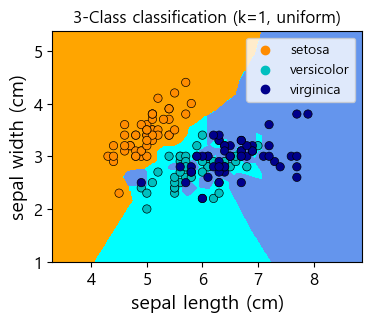

In [38]:
# 시각화를 위한 패키지
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn import neighbors, datasets
import numpy as np

iris=load_iris()

# K-최근접이웃 분류의 시각화를 좌표평면에 하기 위해서는 예측변수를 2개까지만 사용할 수 있음
# sepal length (cm)와 sepal width (cm)의 값만 뽑아 2차 배열로 변환
X2 = np.array(df[predictors[0:2]])

# 그래프 사이즈 설정
plt.figure(figsize=(4,3))

# color map 설정
cmap_light = ListedColormap(['orange', 'cyan','cornflowerblue'])
cmap_bold = ['darkorange', 'c', 'darkblue']

# 앞서 정확도가 가장 높았던 파라미터를 입력함, n이 커질수록 복잡도 감소
neigh2 = neighbors.KNeighborsClassifier(n_neighbors=1, weights='uniform', p=2)
neigh2.fit(X2, y)
 
# 분류 경계를 색으로 구분하기 위한 작업
h = .02  # step size in the mesh
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
Z = neigh2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
 
# 분류 경계 별 색칠하기
plt.contourf(xx, yy, Z, cmap=cmap_light)
 
# 각 훈련값의 좌표들을 그린 산점도
sns.scatterplot(x=X2[:, 0], y=X2[:, 1], hue=iris.target_names[y],
                    palette=cmap_bold, alpha=1.0, edgecolor="black")
 
# 제목에 KNN 분류 파라미터 표기
plt.title("3-Class classification (k=1, uniform)")
plt.xlabel(predictors[0])
plt.ylabel(predictors[1])

plt.show()

---

## Decision Tree
특정 규칙에 따라 레이블 분류

### DT 하이퍼파라미터

**max_depth** : int, default=None  
최대 깊이 지정  

**min_samples_split** : int or float, default=2  
분할되기 위해 노드가 가져야 하는 최고 샘플 수  

**min_samples_leaf** : int or float, default=1  
리프 노드가 가지고 있어야 할 최소 샘플 수  

**max_features** : int, float or {"auto", "sqrt", "log2"}, default=None  
각 노드에서 분할에 사용할 feature의 최대 수  

**max_leaf_nodes** : int, default=None  
리프 노드의 최대수  

### iris 모든 column 이용

In [55]:
# 사용한 데이터 : iris dataset
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data[:, :]
y = iris.target

In [56]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X, y)

DecisionTreeClassifier(random_state=42)

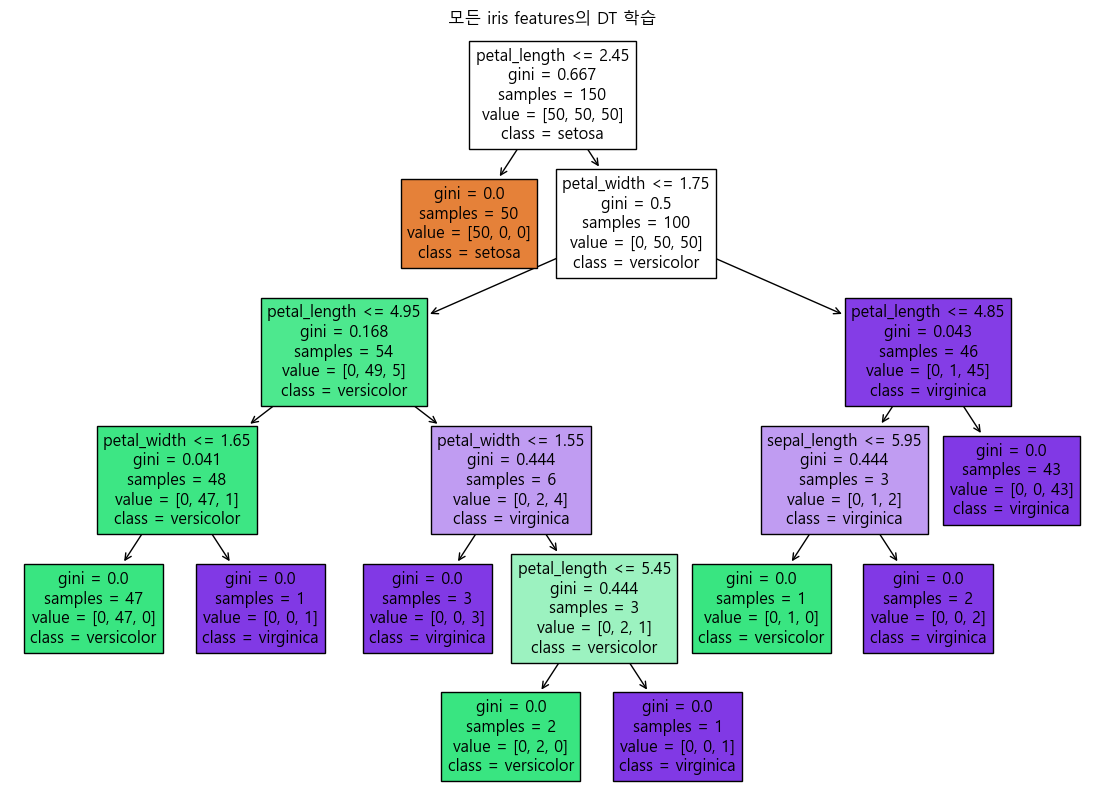

In [57]:
from sklearn.tree import plot_tree

explt_vars = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
fct_val = ['setosa','versicolor','virginica']

plt.figure(figsize=(14,10))
plot_tree(tree_clf, feature_names = explt_vars, class_names = fct_val, filled = True)

plt.title("모든 iris features의 DT 학습") 
plt.show()

### iris 꽃잎 길이&너비 이용 / max_depth=2

In [58]:
explt_vars = ["petal_length", "petal_width"]  # 꽃잎 길이와 너비만 사용
fct_val = ['setosa','versicolor','virginica']

iris = load_iris()
X = iris.data[:, 2:] # 꽃잎 길이와 너비
y = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X, y)

DecisionTreeClassifier(max_depth=2, random_state=42)

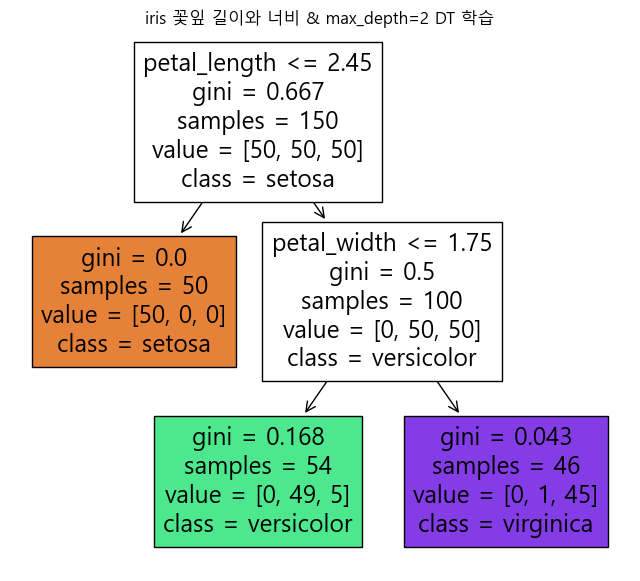

In [59]:
plt.figure(figsize=(8,7))
plot_tree(tree_clf, feature_names = explt_vars, class_names = fct_val, filled = True)

plt.title("iris 꽃잎 길이와 너비 & max_depth=2 DT 학습") 
plt.show()

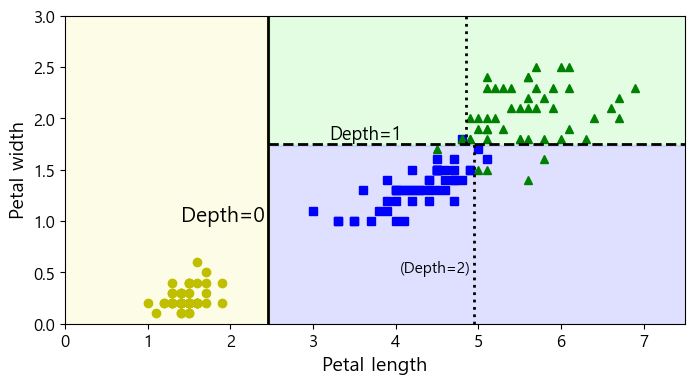

In [44]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, axes=[0, 7.5, 0, 3], iris=True, legend=False, plot_training=True):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    if not iris:
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    if plot_training:
        plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
        plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
        plt.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="Iris virginica")
        plt.axis(axes)
    if iris:
        plt.xlabel("Petal length", fontsize=14)
        plt.ylabel("Petal width", fontsize=14)
    else:
        plt.xlabel(r"$x_1$", fontsize=18)
        plt.ylabel(r"$x_2$", fontsize=18, rotation=0)
    if legend:
        plt.legend(loc="lower right", fontsize=14)

plt.figure(figsize=(8, 4))
plot_decision_boundary(tree_clf, X, y)
plt.plot([2.45, 2.45], [0, 3], "k-", linewidth=2)
plt.plot([2.45, 7.5], [1.75, 1.75], "k--", linewidth=2)
plt.plot([4.95, 4.95], [0, 1.75], "k:", linewidth=2)
plt.plot([4.85, 4.85], [1.75, 3], "k:", linewidth=2)
plt.text(1.40, 1.0, "Depth=0", fontsize=15)
plt.text(3.2, 1.80, "Depth=1", fontsize=13)
plt.text(4.05, 0.5, "(Depth=2)", fontsize=11)

plt.show()

### 클래스 확률 추정

In [45]:
tree_clf.predict_proba([[5, 1.5]]) #꽃잎길이 5, 꽃잎 너비 1,5

array([[0.        , 0.90740741, 0.09259259]])

In [46]:
tree_clf.predict([[5, 1.5]])

array([1])

### 파라미터 변경

### random_state 변경했을 때
random_state는 결정 트리 학습에서 발생하는 무작위성을 제어  
같은 데이터셋이라도 random_state가 다르면 동일한 정보 이득을 제공하는 feature들 중 어느 것을 먼저 선택하는지가 달라지며,  
분할 기준 값도 다르게 설정될 수 있음  
==> 트리의 분할 구조와 결정 경계가 달라짐  

In [47]:
tree_clf_tweaked = DecisionTreeClassifier(max_depth=2, random_state=40)
tree_clf_tweaked.fit(X, y)

DecisionTreeClassifier(max_depth=2, random_state=40)

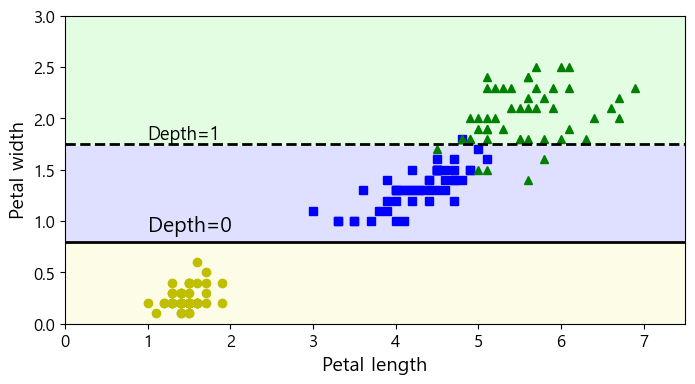

In [48]:
plt.figure(figsize=(8, 4))
plot_decision_boundary(tree_clf_tweaked, X, y, legend=False)
plt.plot([0, 7.5], [0.8, 0.8], "k-", linewidth=2)
plt.plot([0, 7.5], [1.75, 1.75], "k--", linewidth=2)
plt.text(1.0, 0.9, "Depth=0", fontsize=15)
plt.text(1.0, 1.80, "Depth=1", fontsize=13)

plt.show()

### min_samples_leaf 변경 

분할되기 위해 노드가 가져야 하는 최고 샘플 수  
작게 설정할 수록 분할되는 노드가 많아져 과적합 가능성 증가  

In [49]:
# 사용한 데이터 : make_moons
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=100, noise=0.25, random_state=53)

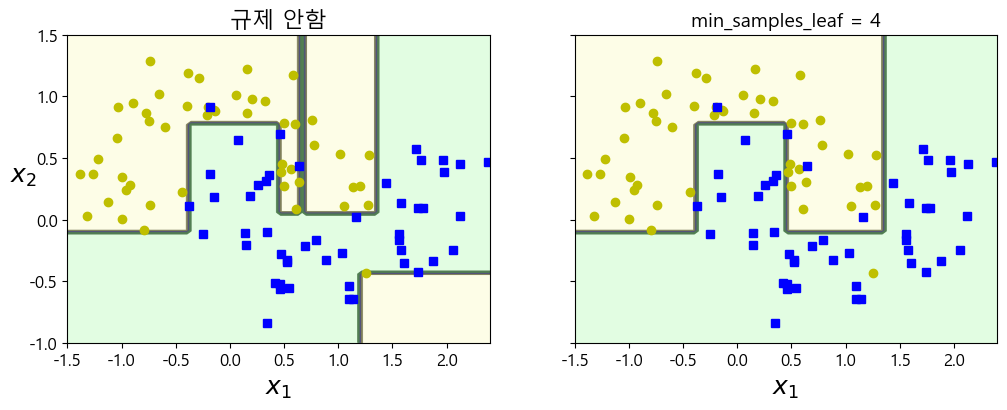

In [50]:
deep_tree_clf1 = DecisionTreeClassifier(random_state=42)
deep_tree_clf2 = DecisionTreeClassifier(min_samples_leaf=4, random_state=42)
deep_tree_clf1.fit(X, y)
deep_tree_clf2.fit(X, y)

fig, axes = plt.subplots(ncols=2, figsize=(12, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(deep_tree_clf1, X, y, axes=[-1.5, 2.4, -1, 1.5], iris=False)
plt.title("규제 안함", fontsize=16)
plt.sca(axes[1])
plot_decision_boundary(deep_tree_clf2, X, y, axes=[-1.5, 2.4, -1, 1.5], iris=False)
plt.title("min_samples_leaf = {}".format(deep_tree_clf2.min_samples_leaf), fontsize=14)
plt.ylabel("")

plt.show()